In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('airline_passengers.csv', index_col='Month', parse_dates=True)

In [3]:
df.head(50)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


<Axes: xlabel='Month'>

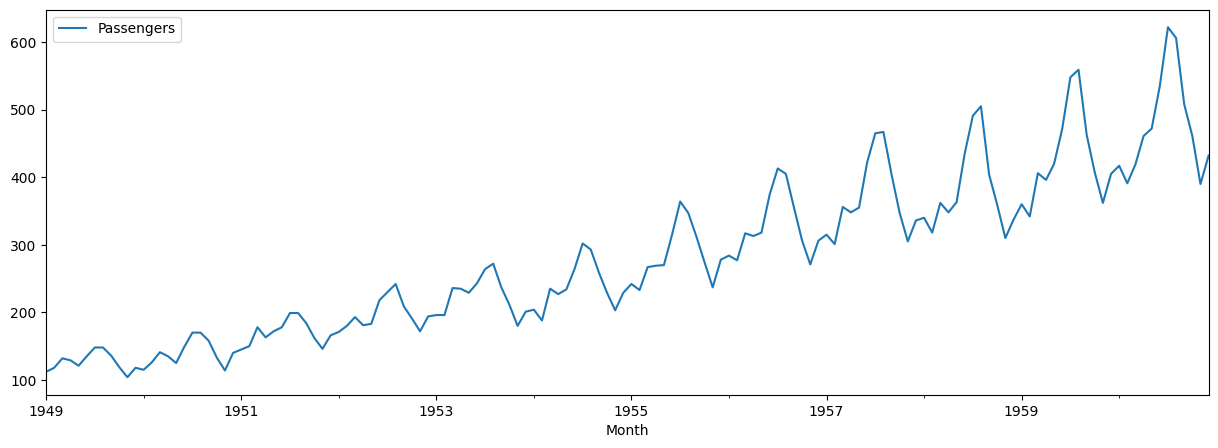

In [4]:
df.plot(figsize=(15, 5))

In [5]:
df['1stdiff'] = df['Passengers'].diff()

<Axes: xlabel='Month'>

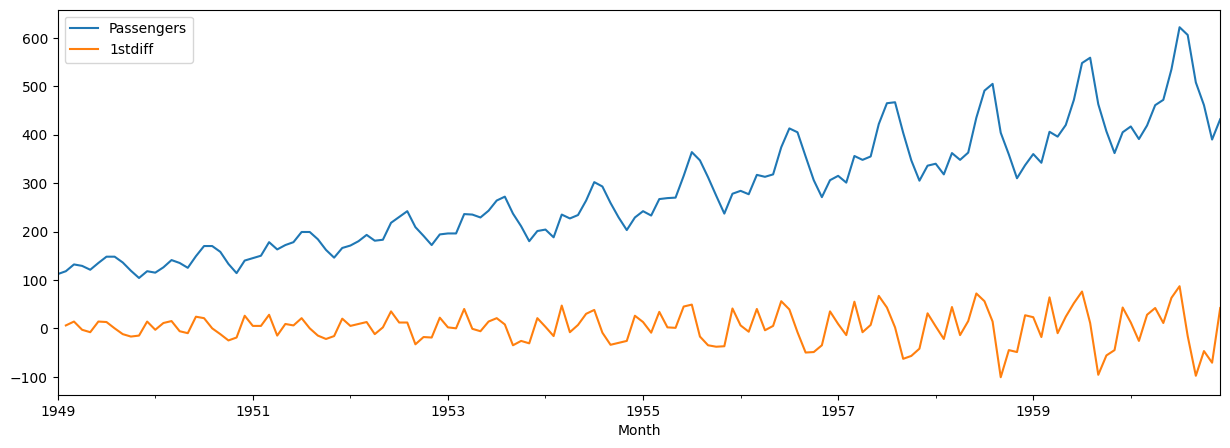

In [6]:
df.plot(figsize=(15, 5))

<Axes: xlabel='Month'>

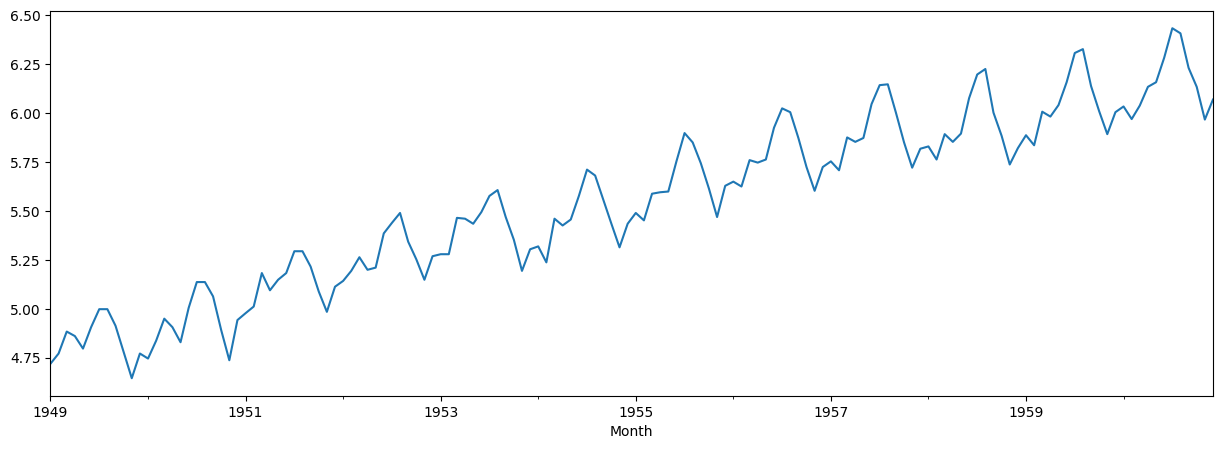

In [7]:
df['LogPassengers'] = np.log(df['Passengers'])
df['LogPassengers'].plot(figsize=(15, 5))

## RNN

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, LSTM, GlobalMaxPooling1D
from tensorflow.keras.models import Model

In [9]:
df['DiffLogPassengers'] = df['LogPassengers'].diff()
series = df['DiffLogPassengers'].dropna().to_numpy()

T = 20
X = []
Y = []

for t in range(len(series) - T):
  x = series[t:t+T]
  X.append(x)
  y = series[t+T]
  Y.append(y)
print(np.array(X).shape)
X = np.array(X).reshape(-1, T, 1)
Y = np.array(Y)

print("X.shape: ", X.shape, "Y.shape: ", Y.shape)


(123, 20)
X.shape:  (123, 20, 1) Y.shape:  (123,)


In [11]:
Ntest = 12
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:]

In [12]:
i = Input(shape=(T, 1))
x = LSTM(32)(i)
x = Dense(16, activation='relu')(x)
x = Dense(1)(x)
model = Model(i, x)

In [13]:
## 4 * ((m*n) + (n * n) + n), m = input features, n = LSTM cells
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 20, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(loss='mse', optimizer='adam')
r = model.fit(Xtrain, Ytrain, epochs=100, validation_data=(Xtest, Ytest))

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - loss: 0.0117 - val_loss: 0.0115
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0115 - val_loss: 0.0112
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0114 - val_loss: 0.0111
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0112 - val_loss: 0.0110
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0110 - val_loss: 0.0110
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0110 - val_loss: 0.0108
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0109 - val_loss: 0.0105
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0107 - val_loss: 0.0104
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0105 - val_loss: 0.0102
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0104 - val_loss: 0.0101
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0101 - val_l

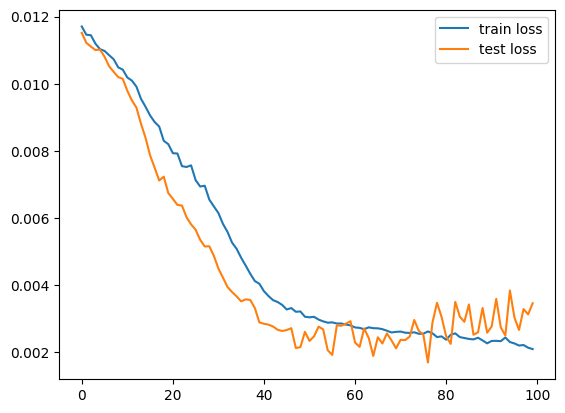

In [15]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='test loss')
plt.legend()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


<Axes: xlabel='Month'>

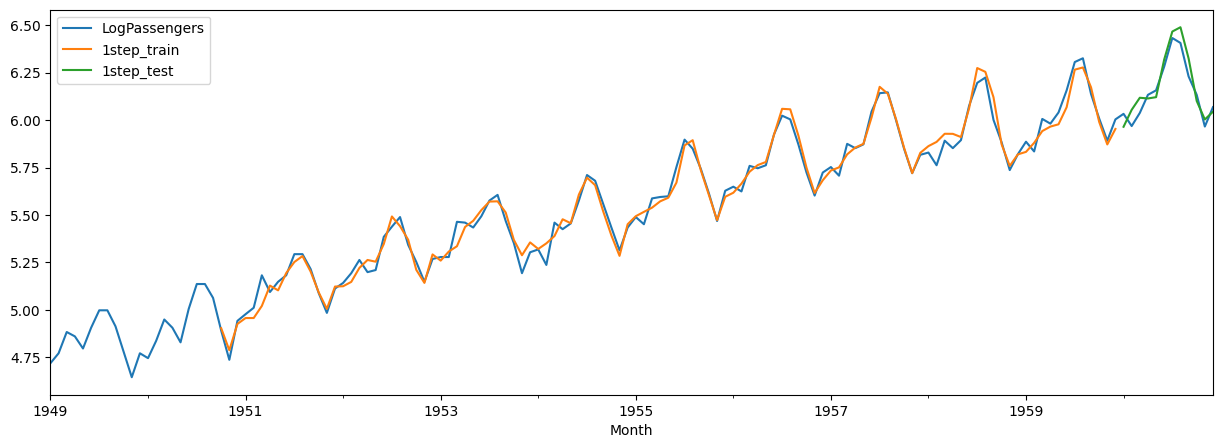

In [17]:
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

train_idx = df.index <= train.index[-1]
test_idx = df.index > train.index[-1]
# vt+1 = dift + vt -> vt+1 - vt + vt
train_idx[:T+1] = False # primele T+1 valori nu sunt de prezis
Ptrain = model.predict(Xtrain).flatten()
Ptest = model.predict(Xtest).flatten()
df['ShiftLogPassengers'] = df['LogPassengers'].shift(1)
prev = df['ShiftLogPassengers']
last_train = train.iloc[-1]['LogPassengers']
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

df[['LogPassengers', '1step_train', '1step_test']].plot(figsize=(15,5))


In [18]:
Ptest = model.predict(Xtest).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


<Axes: xlabel='Month'>

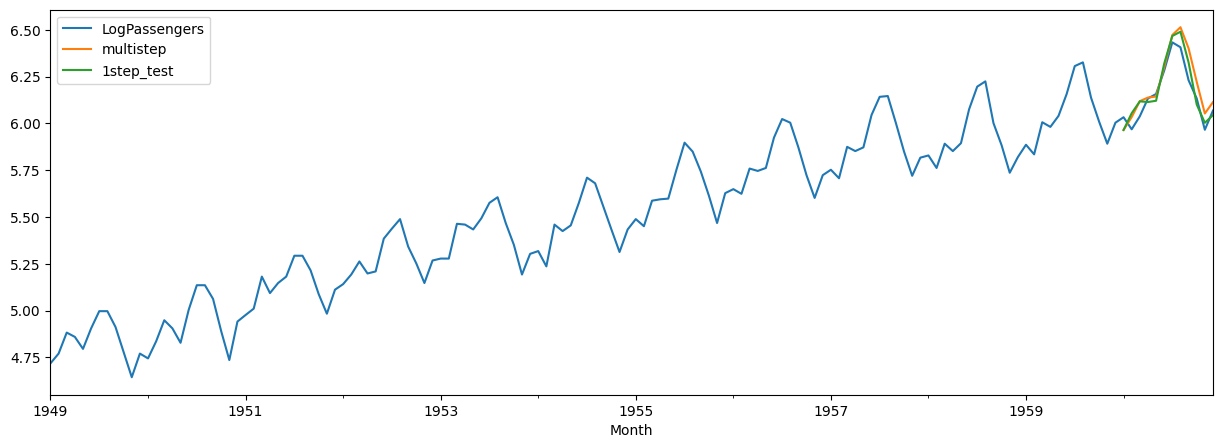

In [19]:
## multi step prediction
multistep_predictions = []

last_x = Xtest[0]
while len(multistep_predictions) < Ntest:
  p = model.predict(last_x.reshape(1, -1, 1))[0]
  multistep_predictions.append(p)

  last_x = np.roll(last_x, -1)
  last_x[-1] = p

df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

df[['LogPassengers', 'multistep', '1step_test']].plot(figsize=(15,5))



In [20]:
Tx = T
Ty = Ntest

X = []
Y = []

for t in range(len(series) - Tx - Ty + 1):
  x = series[t:t+Tx]
  X.append(x)
  y = series[t+Tx:t+Tx+Ty]
  Y.append(y)

X = np.array(X).reshape(-1, Tx, 1)
Y = np.array(Y).reshape(-1, Ty)
print("X.shape: ", X.shape, "Y.shape: ", Y.shape)

X.shape:  (112, 20, 1) Y.shape:  (112, 12)


In [21]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [22]:
i = Input(shape=(Tx, 1))
x = LSTM(16, return_sequences=True)(i)
x = LSTM(32, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)
x = Dense(Ty)(x)

model = Model(i, x)

In [23]:
model.compile(loss='mse', optimizer='adam')
r = model.fit(Xtrain_m, Ytrain_m, epochs=300, validation_data=(Xtest_m, Ytest_m))

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - loss: 0.0113 - val_loss: 0.0113
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0112 - val_loss: 0.0114
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0111 - val_loss: 0.0113
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0111 - val_loss: 0.0114
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0111 - val_loss: 0.0114
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0111 - val_loss: 0.0116
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0110 - val_loss: 0.0117
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0110 - val_loss: 0.0117
Epoch 9/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0110 - val_loss: 0.0113
Epoch 10/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0110 - val_loss: 0.0111
Epoch 11/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0109 - val_loss: 0.0111
Epoch 12/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0108 - val_l

In [24]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


In [25]:
Ptrain

array([[-0.16349779, -0.06418404,  0.03727017, ...,  0.11911204,
         0.01870283, -0.09966202],
       [-0.0582446 ,  0.02512253,  0.01314961, ..., -0.02311071,
        -0.05101958, -0.08318433],
       [ 0.10121062,  0.04440654,  0.02428441, ..., -0.09939587,
        -0.12471278, -0.09238484],
       ...,
       [-0.12437686, -0.11828435,  0.01083266, ...,  0.10657427,
        -0.00952718, -0.14299905],
       [-0.11694513,  0.03354508,  0.07222287, ...,  0.03449086,
        -0.14149833, -0.18326697],
       [ 0.04937734,  0.01934358,  0.06636604, ..., -0.15587044,
        -0.15900047, -0.10433917]], dtype=float32)

In [26]:
Ptest = Ptest[0]

<Axes: xlabel='Month'>

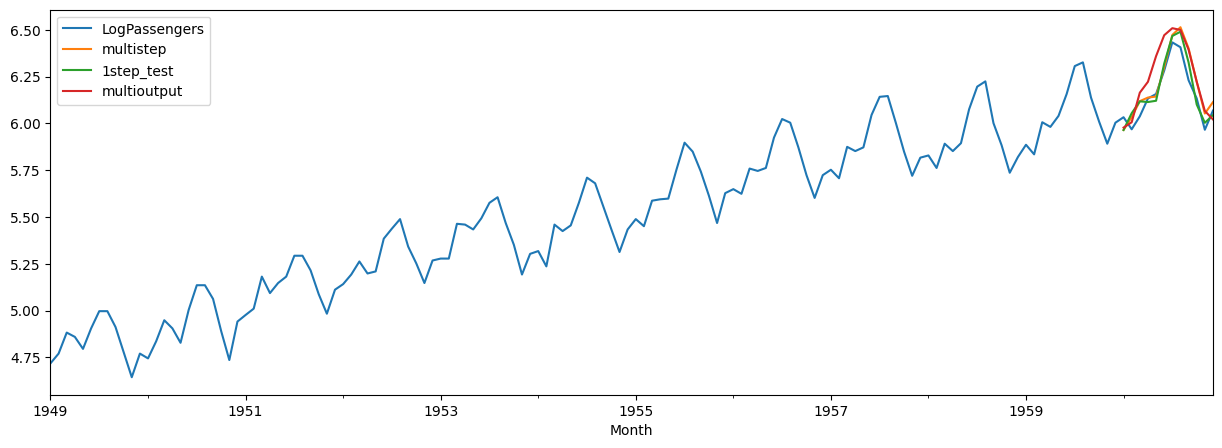

In [27]:
df.loc[test_idx, 'multioutput'] = last_train + np.cumsum(Ptest)
df[['LogPassengers', 'multistep', '1step_test', 'multioutput']].plot(figsize=(15,5))